<a href="https://colab.research.google.com/github/nithinpocharam/ai-engineering-course/blob/main/rag_chromadb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **RAG: Retrieval Augmented Generation**

### **What is RAG?**

RAG is the technique of grounding model's responses by letting them retrieve real time data from knowledge bases. It's used to make AI more personalized and reliable.


### **Why do we need RAG?**

> LLMs are frozen in time

They know nothing about your private documents or anything past their training cutoff. Retrieval-Augmented Generation (RAG) solves this by giving the model a reference knowledge to consult before answering.

In [1]:
!pip install -q chromadb sentence-transformers requests groq "opentelemetry-api<1.39.0" "opentelemetry-sdk<1.39.0"

### **Steps In RAG**

1. **Ingestion:** Preparing, embedding & storing the data

2. **Retrieval:** Finding relevant document to put in context

3. **Generation:** Prompting the llm with retrieved context to generate grounded response.

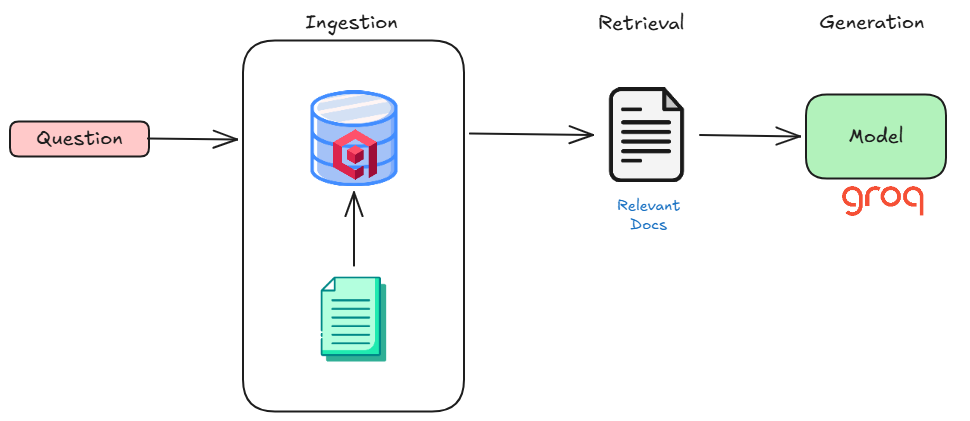

### **What are we going to build?**

An HR Policies Chatbot, that can answer about AtliqAI's HR Policies using RAG.


## **First Step: Ingestion**

Ingestion itself involves multiple steps:

- **Loading** the docuemnts into a readable format
- **Chunking**: Splitting them into smaller chunks
- **Embedding**: Creating their embeddings using the embedding models
- **Indexing**: Storing the embeddings and payloads on the vector DB

### **Loading**

The first step is loading the document so that we can process it.

In [2]:
# Loading the Document
import os
import requests

GITHUB_RAW_URL = "https://raw.githubusercontent.com/tnahddisttud/sample-doc/refs/heads/main/atliqai_hr_policies.txt"

def load_document(url: str) -> str:
    """Fetch a plain-text file from a raw GitHub URL."""
    response = requests.get(url, timeout=10)
    response.raise_for_status()
    return response.text

raw_text = load_document(GITHUB_RAW_URL)
print(f"Loaded {len(raw_text):,} characters")
print(raw_text[:400])  # Sanity check

Loaded 16,864 characters
# AtliqAI HR Policies

AtliqAI is committed to building a transparent, inclusive, and high-performance workplace. This document outlines the policies and guidelines that govern employment, conduct, compensation, and well-being at AtliqAI. All employees are expected to read, understand, and adhere to these policies from their first day of joining.

---

## Employment & Onboarding

### Offer and Joi


### **Chunking**
It's an essential preprocessing step where we break down large documents into smaller, manageable, and semantically meaningful text segments.

It optimizes RAG by ensuring retrieval accuracy, fitting content into LLM context windows, and reducing retrieval time.

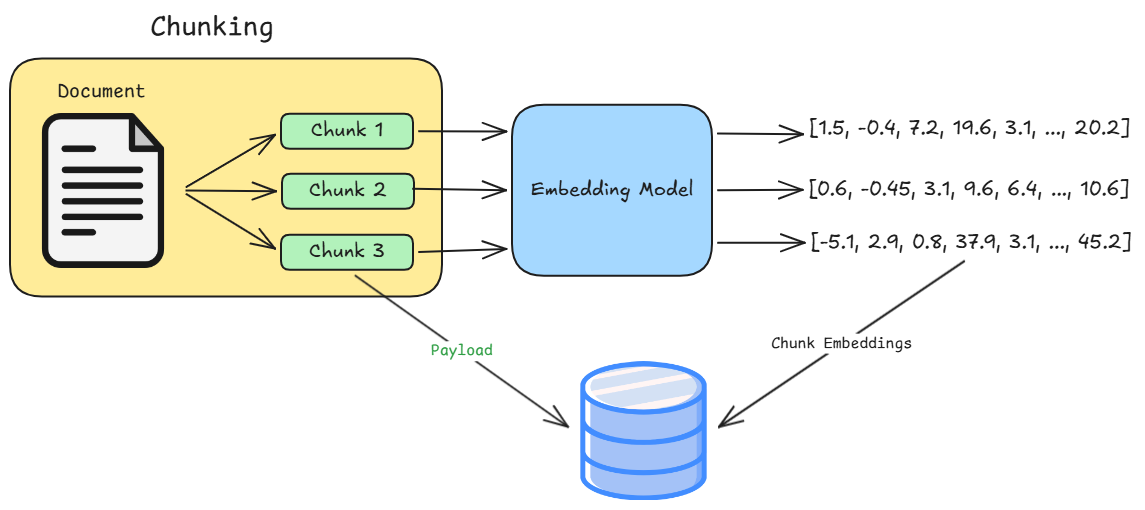





In [3]:
CHUNK_SIZE = 50

def parse_word_chunks(text: str, chunk_size: int = CHUNK_SIZE) -> list[dict]:
    # Strip markdown heading symbols and blank lines
    clean_lines = []
    for line in text.splitlines():
        line = line.strip().lstrip("#").strip()
        if line:
            clean_lines.append(line)

    # Join everything into one word list and slice
    words = " ".join(clean_lines).split()

    chunks = []
    for i in range(0, len(words), chunk_size):
        content = " ".join(words[i : i + chunk_size])
        chunks.append({
            "chunk_index": len(chunks),
            "content": content,
        })

    return chunks

In [4]:
chunks = parse_word_chunks(raw_text)
print(f"Total chunks: {len(chunks)}")

Total chunks: 51


In [5]:
# Inspect a chunk
for chunk in chunks[:3]:
    print("─" * 55)
    print(f"Content : {chunk['content'][:200]}…")

───────────────────────────────────────────────────────
Content : AtliqAI HR Policies AtliqAI is committed to building a transparent, inclusive, and high-performance workplace. This document outlines the policies and guidelines that govern employment, conduct, compe…
───────────────────────────────────────────────────────
Content : & Onboarding Offer and Joining Formalities Upon acceptance of an offer letter, candidates must complete the joining formalities within the stipulated date mentioned in the offer. The HR team will shar…
───────────────────────────────────────────────────────
Content : photograph. Failure to submit required documents within 7 working days of joining may result in withholding of the first salary disbursement. Probation Period All new employees at AtliqAI are placed o…


In [6]:
def build_chunk_text(chunk: dict) -> str:
    return chunk["content"]

### **Embedding**

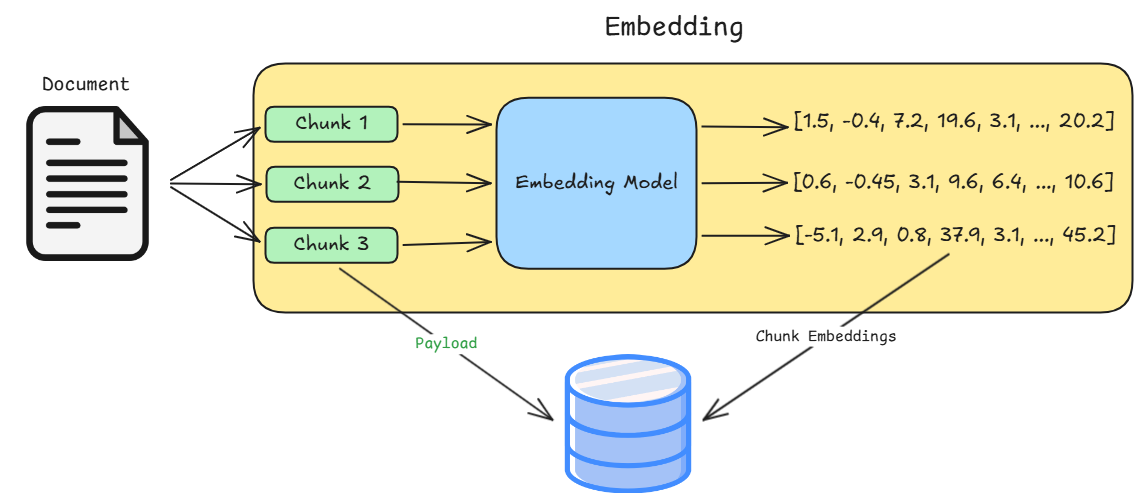

In [7]:
from sentence_transformers import SentenceTransformer

EMBEDDING_MODEL = "all-MiniLM-L6-v2"
embedder = SentenceTransformer(EMBEDDING_MODEL)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [8]:
# Extract Chunk Texts
chunk_texts = [build_chunk_text(c) for c in chunks]

print(f"Embedding {len(chunk_texts)} chunks …")
embeddings = embedder.encode(chunk_texts, show_progress_bar=True)

print(f"Shape: {embeddings.shape}")

Embedding 51 chunks …


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Shape: (51, 384)


### **Indexing**

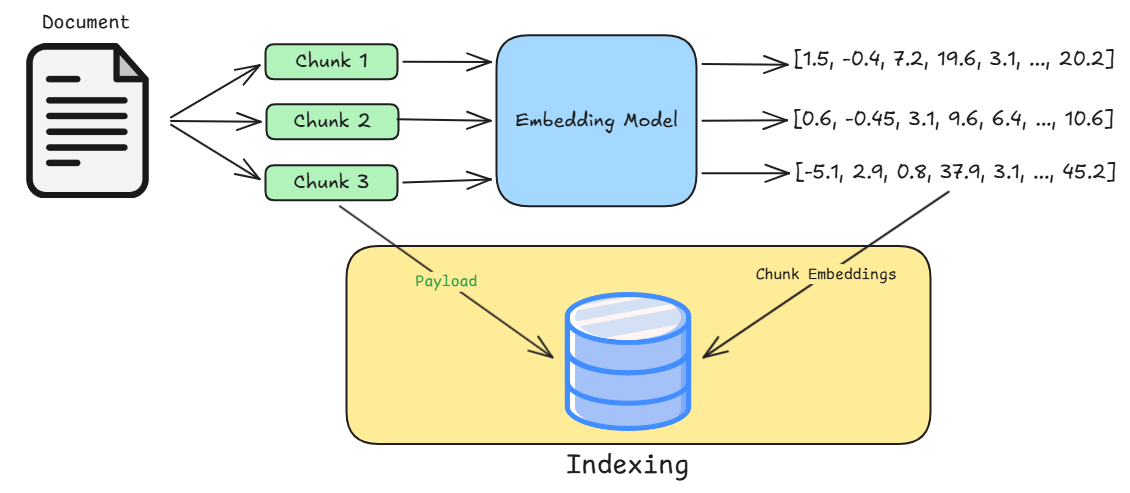

In [10]:
import chromadb # Fixed the spelling here

chroma_client = chromadb.Client()

COLLECTION_NAME = "hrdocs"

DIM = embedder.get_sentence_embedding_dimension()

collection = chroma_client.create_collection(
    name = COLLECTION_NAME,
    metadata = {"hnsw:space":"cosine"}
)

print(f"Collection '{COLLECTION_NAME}' created successfully!")
print(f"Chroma will automatically accept your {DIM}-dimension embeddings on .add()")

Collection 'hrdocs' created successfully!
Chroma will automatically accept your 384-dimension embeddings on .add()


/tmp/ipykernel_7741/49817385.py:7: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  DIM = embedder.get_sentence_embedding_dimension()


In [11]:
# Adding embeddings to chromadb collection

# 1. Ensure IDs are string format (Chroma DB requirement)
my_ids = [str(c["chunk_index"]) for c in chunks]

# 2. Convert NumPy array from embedder.encode into a standard list of float lists
ready_embeddings = embeddings.tolist()

# 3. Add directly to your collection
collection.add(
    ids = my_ids,
    embeddings = ready_embeddings,
    documents = chunk_texts
)

print(f"Successfully added {collection.count()} chunks to the '{COLLECTION_NAME}' collection!")

Successfully added 51 chunks to the 'hrdocs' collection!


## **Retrieval**

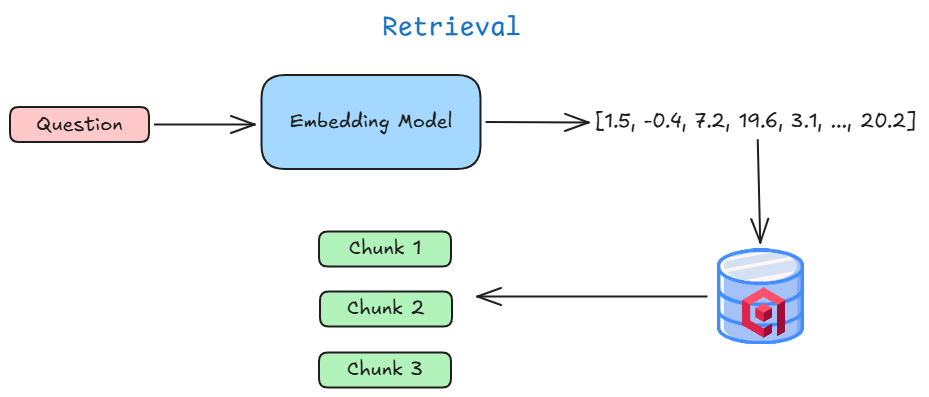

In [16]:
def retrieve(
    query: str,
    top_k: int = 5
) -> list[dict]:
    """
    Embed the query and return the top-k most similar chunks from Chroma.

    Args:
        query          : User's question.
        top_k          : Number of chunks to return.
    """
    # 1. Embed your search query
    query_vector = embedder.encode(query).tolist()

    # 2. Query the collection using the vector
    results = collection.query(
        query_embeddings=[query_vector],
        n_results=top_k
    )

    # 3. Extract the inner lists (index 0) because we only passed a single query
    matched_docs = results['documents'][0]
    matched_distances = results['distances'][0]
    matched_ids = results['ids'][0]

    # 4. Zip the flat lists together into your dictionary format
    formatted_hits = []
    for doc, distance, doc_id in zip(matched_docs, matched_distances, matched_ids):
      formatted_hits.append({
          "content":doc,
          "chunk_index":int(doc_id),
          # Note: Chroma returns cosine distance (0.0 is perfect match).
          # Use `round(1.0 - distance, 4)` if you want a similarity score instead.
          "score": round(1.0 - distance,4)
      })

    return formatted_hits

In [17]:
# --- Execute and Print Results ---
results = retrieve("What is the leave policy")
for r in results:
    print(f"[score={r['score']}]")
    print(f"  {r['content'][:200]}…\n")

[score=0.5588]
  Policy Casual Leave Every confirmed employee is entitled to 12 casual leaves per calendar year, credited at 1 leave per month. Casual leave can be availed for personal errands, minor illness, or unpla…

[score=0.4643]
  of more than 2 consecutive days. Unused sick leaves up to a maximum of 10 can be carried forward to the following year. Earned Leave Employees accrue earned leave at the rate of 1.25 days per month, a…

[score=0.4214]
  earned leaves (up to the carry-forward limit), reimbursement of pending expense claims, and deduction of any outstanding dues or advances. The relieving letter and experience certificate will be issue…

[score=0.415]
  be carried forward to the next calendar year and lapse on December 31st. Sick Leave Employees are entitled to 10 sick leaves per calendar year. Sick leave can be availed in case of illness, hospitalis…

[score=0.401]
  HR team. The purpose of the exit interview is to gather feedback on the employee's experience at AtliqAI,

## **RAG Pipeline**

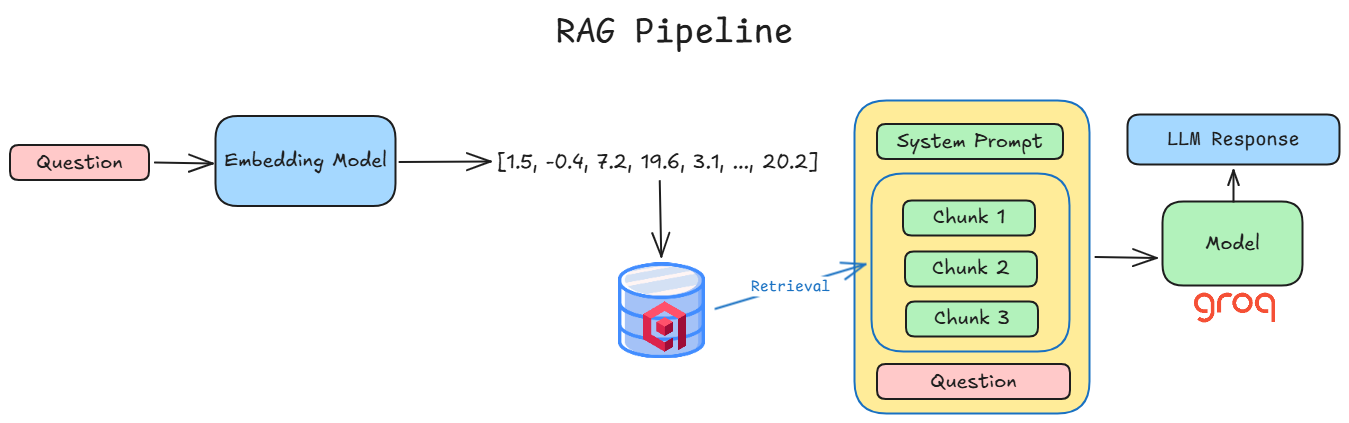

In [18]:
SYSTEM_PROMPT = """You are a helpful HR assistant.
Answer the user's question using ONLY the context provided below.
If the context does not contain enough information, say so — do not make things up.
Always cite the section name when referencing specific information."""

In [19]:
def build_context(retrieved_chunks: list[dict]) -> str:
    parts = []
    for i, chunk in enumerate(retrieved_chunks, 1):
        parts.append(f"[Source {i}]\n{chunk['content']}")
    return "\n\n---\n\n".join(parts)

## Setting up Groq for LLM Inference

**💡What is Groq?**

A platform that serves LLMs and provides access to OpenSource models in their freetier

---

**💡How to access models on Groq?**
 1. Visit : https://console.groq.com/keys
 2. Create an account using your email ID
 3. Click on the "Create API Key" button and enter a name for the key (we are using "CB_LangChain"
 4. Copy the generated key and paste it some where save
 5. Run the code below and paste the groq API Key in the text box

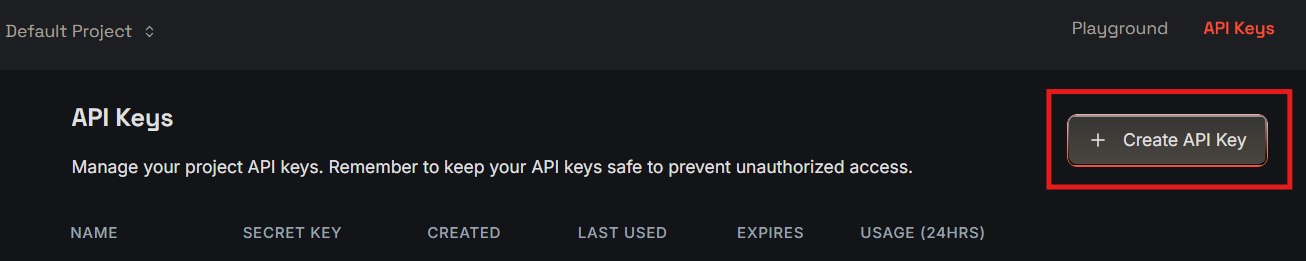

In [20]:
import getpass
import os

if "GROQ_API_KEY" not in os.environ:
    os.environ["GROQ_API_KEY"] = getpass.getpass("Enter your Groq API key: ")

Enter your Groq API key: ··········


### **End-to-end RAG pipeline:**
  1. Retrieve relevant chunks from Qdrant
  2. Format them as a context block
  3. Send context + query to Groq and return the answer

In [21]:
from groq import Groq

groq_client = Groq()   # Reads GROQ_API_KEY from environment automatically
GROQ_MODEL  = "openai/gpt-oss-safeguard-20b"

def rag(query: str, top_k: int = 5):
    """
    End-to-end RAG pipeline:
      1. Retrieve relevant chunks from Qdrant
      2. Format them as a context block
      3. Send context + query to Groq and return the answer
    """
    # Step 1 — Retrieve
    chunks = retrieve(query, top_k=top_k)
    if not chunks:
        return "No relevant content found in the document."

    # Step 2 — Build context
    context = build_context(chunks)

    # Step 3 — Generate
    user_message = f"Context:\n{context}\n\nQuestion: {query}"

    response = groq_client.chat.completions.create(
        model=GROQ_MODEL,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": user_message},
        ],
        temperature=0.2,   # Low = factual;  High = creative
    )
    return response.choices[0].message.content, context

In [22]:
answer, context = rag("What are the main topics covered in this document?")
print(answer)
print(f"{250*'='}")
print(f"\n\nSOURCES:\n {context}")

The document covers several key HR‑related areas at AtliqAI:

1. **Employment** – general policies governing work conduct, compensation, and workplace culture.  
2. **Data Privacy & Confidentiality** – rules around the collection and processing of employee personal data.  
3. **Onboarding (Offer and Joining Formalities)** – procedures and required documentation for new hires.  
4. **Health Insurance** – group coverage details for employees and their dependents.  
5. **Grievance Redressal** – processes for raising and resolving work‑related concerns.  
6. **Exit Interview** – purpose and procedure for gathering feedback from departing employees.


SOURCES:
 [Source 1]
AtliqAI HR Policies AtliqAI is committed to building a transparent, inclusive, and high-performance workplace. This document outlines the policies and guidelines that govern employment, conduct, compensation, and well-being at AtliqAI. All employees are expected to read, understand, and adhere to these policies from their 